In [1]:
import DataPipeline
import diffusion
import model
import train
from pathlib import Path
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
dataset = DataPipeline.PointCloudDataset(number_points=256)
point_cloud = dataset[3]
dataloader = DataLoader(dataset[3], shuffle=False, batch_size=1)
T_max = 5000
#resnet = model.ResNet(number_points=512, in_channels=3, hidden_channels=64, out_channels=3, t_dim=256).to(device)
resnet = model.Denoiser(256)
diffuser = model.Diffuser()
#resnet = model.ResNet2(number_points=256, in_channels=3, hidden_channels=32, out_channels=3, t_dim=128).to(device)
num_parameters = sum(p.numel() for p in resnet.parameters() if p.requires_grad)
print(f"Trainable Parameters: {num_parameters / 1e6:.2f}M")
#diffuser = diffusion.DiffusionSchedule(timesteps=1000, device=device)
#diffuser2 = diffusion.DDPM(1000)

#optimizer = torch.optim.AdamW(resnet.parameters(), lr=2e-4, weight_decay=1e-4)
optimizer = torch.optim.Adam(resnet.parameters(), lr=2e-4)
#scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=T_max // 4, gamma=0.5)
scheduler = None


Trainable Parameters: 0.82M


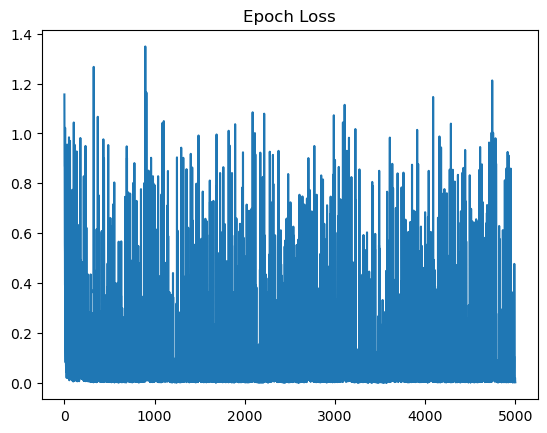

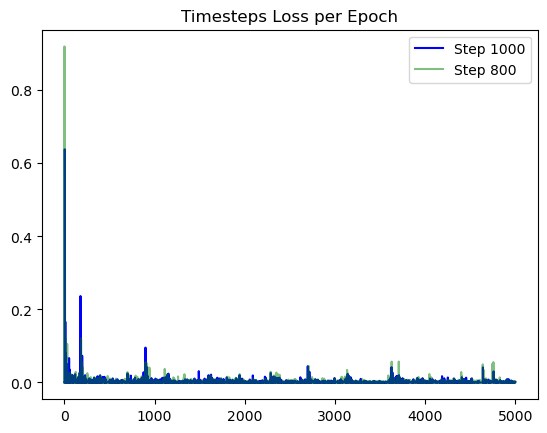

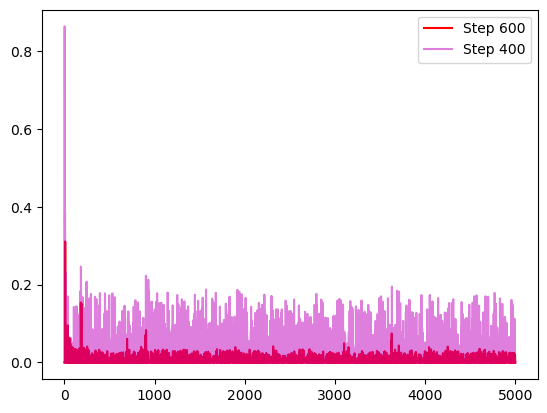

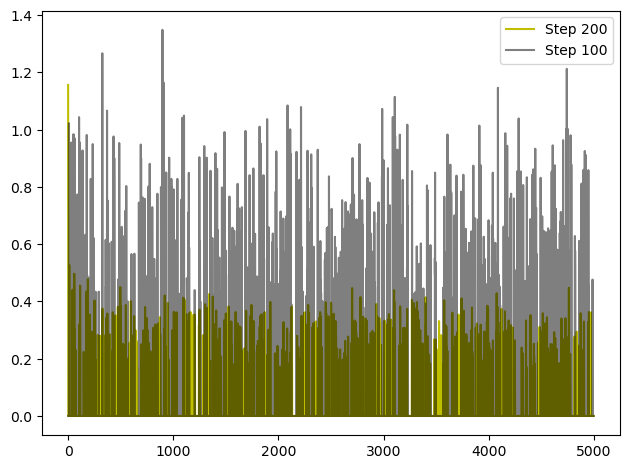

In [3]:
loss_history = []
step1000_loss = []
step800_loss = []
step600_loss = []
step400_loss = []
step200_loss = []
step100_loss = []

for epoch in range(T_max):
    best_loss = 1e6
    epoch_loss, loss_1000, loss_800, loss_600, loss_400, loss_200, loss_100 = train.train_one_epoch(resnet, dataloader, diffuser, optimizer, device, grad_clip=None, permute=True)
    #epoch_loss = train.train(resnet, diffuser2, dataloader, optimizer)
    loss_history.append(epoch_loss)
    step1000_loss.append(loss_1000)
    step800_loss.append(loss_800)
    step600_loss.append(loss_600)
    step400_loss.append(loss_400)
    step200_loss.append(loss_200)
    step100_loss.append(loss_100)

    if scheduler is not None:
        scheduler.step()

    if epoch_loss < best_loss:
        best_loss = epoch_loss
        torch.save(resnet.state_dict(), Path.cwd() / Path("ddpm.pt"))

fig = plt.figure()

plt.title("Epoch Loss")
plt.plot(loss_history)
plt.figure()
plt.title("Timesteps Loss per Epoch")
plt.plot(step1000_loss, color="b", label="Step 1000")
plt.plot(step800_loss, color="g", label="Step 800", alpha=0.5)
plt.legend()
plt.figure()
plt.plot(step600_loss, color="r", label="Step 600")
plt.plot(step400_loss, color="m", label="Step 400", alpha=0.5)
plt.legend()
plt.figure()
plt.plot(step200_loss, color="y", label="Step 200")
plt.plot(step100_loss, color="k", label="Step 100", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
#x_pred = train.sample_point_clouds(resnet, diffuser, size=256)
x_pred = model.sample_ddpm(resnet, diffuser, 256)

torch.Size([256, 3])


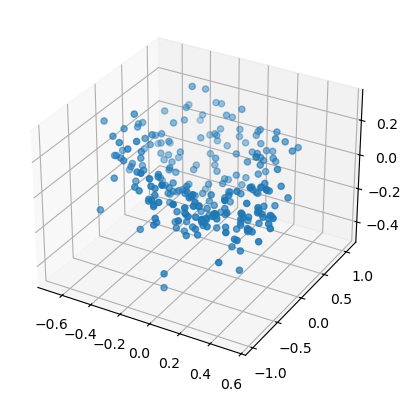

In [9]:
point_clouds_xprev_end = x_pred[0]
print(point_clouds_xprev_end.shape)
fig = plt.figure()
ax = fig.add_subplot(projection="3d")
ax.scatter(point_clouds_xprev_end[:, 0], point_clouds_xprev_end[:, 1], point_clouds_xprev_end[:, 2])

torch.Size([1, 3, 512])


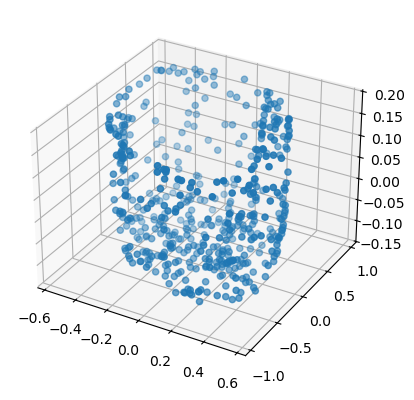

In [10]:
print(point_cloud.shape)
fig = plt.figure()
ax = fig.add_subplot(projection="3d")
ax.scatter(point_cloud[0, 0, :], point_cloud[0, 1, :], point_cloud[0, 2, :])